# Prepocesing - Hasil penghapusan Outlier

Pada prepocesing ini saya menggunakan library pyod untuk penghapusan oulier, dimana saya menggunakan 3 metode yaitu:
- KNN
- Abod
- Lof

In [1]:
!pip install pyod


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


Dataset yang digunakan adalah Iris dataset dimana saya mengambil bawaan dari scikit-learn. Dataset ini berisi 150 sampel bunga Iris dengan 4 fitur numerik: panjang dan lebar sepal, serta panjang dan lebar petal. Dataset juga memiliki kolom target yang menunjukkan spesies bunga (setosa, versicolor, virginica).

Dimana yang pertama ini saya Memuat dataset dimana dataset dimuat ke dalam DataFrame pandas agar mudah diolah. yang kedua saya mengubah nama kolom, misalnya "sepal length (cm)" menjadi "sepal.length". yang ketiga saya menambahkan kolom target variety dimana kolom target asli (target) diubah menjadi nama spesies bunga, sehingga lebih mudah dibaca. yang keempat saya menghapus kolom target asli: Agar tidak redundan dan memudahkan analisis. dan yang terakhir adalah mengecek data dimana dicek ukuran dataset dan ditampilkan beberapa baris pertama untuk memastikan data sudah benar.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca dataset original
print("Membaca dataset awal...")
df = pd.read_csv("data-iris.csv")

# Rename kolom agar konsisten
df.rename(columns={
    "sepal length (cm)": "sepal.length",
    "sepal width (cm)": "sepal.width",
    "petal length (cm)": "petal.length",
    "petal width (cm)": "petal.width"
}, inplace=True)

# Pilih fitur numerik
features = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
X = df[features].values

# Mapping kolom vnum → variety
target_names = {0: "setosa", 1: "versicolor", 2: "virginica"}
df["variety"] = df["vnum"].map(target_names)

# Informasi awal dataset
print("Informasi dataset sebelum preprocessing:")
print(f"Jumlah total data: {len(df)}")
print("\nStatistik deskriptif sebelum penghapusan outlier:")
print(df[features].describe())

print("\nContoh data:")
print(df.head())


Membaca dataset awal...
Informasi dataset sebelum preprocessing:
Jumlah total data: 150

Statistik deskriptif sebelum penghapusan outlier:
       sepal.length  sepal.width  petal.length  petal.width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Contoh data:
   sepal.length  sepal.width  petal.length  petal.width variety  vnum
0           5.1          3.5           1.4          0.2  setosa     0
1           4.9          3.0           1.4          0.2  setosa     0
2           4.7          3.2           1.3          0.2  setosa     0
3           4.6          3.

Pada tahap ini, hanya fitur yang numerik yang akan diambil dari dataset Iris, yaitu: sepal_length, sepal_width, petal_length, petal_width, dan vnum ini juga termasuk ke tipe numerik.

Dataset numerik ini yang tampil dibawah berisi 150 sampel dengan 5 kolom

In [8]:
# --- Ambil hanya fitur numerik ---
X = df.select_dtypes("number")
print("\n---Fitur Numerik---")
print("="*60)
print(X)


---Fitur Numerik---
     sepal.length  sepal.width  petal.length  petal.width  vnum
0             5.1          3.5           1.4          0.2     0
1             4.9          3.0           1.4          0.2     0
2             4.7          3.2           1.3          0.2     0
3             4.6          3.1           1.5          0.2     0
4             5.0          3.6           1.4          0.2     0
..            ...          ...           ...          ...   ...
145           6.7          3.0           5.2          2.3     2
146           6.3          2.5           5.0          1.9     2
147           6.5          3.0           5.2          2.0     2
148           6.2          3.4           5.4          2.3     2
149           5.9          3.0           5.1          1.8     2

[150 rows x 5 columns]


Pada tahap ini saya menggunakan tiga metode deteksi outlier untuk membersihkan dataset Iris:

- KNN (K-Nearest Neighbors)
- ABOD (Angle-Based Outlier Detection)
- LOF (Local Outlier Factor)


Dan untuk haasil penghapusan outliernya adalah 

- Dataset aslinya ada 150 baris × 5 kolom
- Setelah KNN, ABOD, atau LOF: 135 baris × 6 kolom

Kolomnya tetap sama, hanya saja baris outliernya yang dihapus.


--- KNN ---
Jumlah outlier: 15 sampel


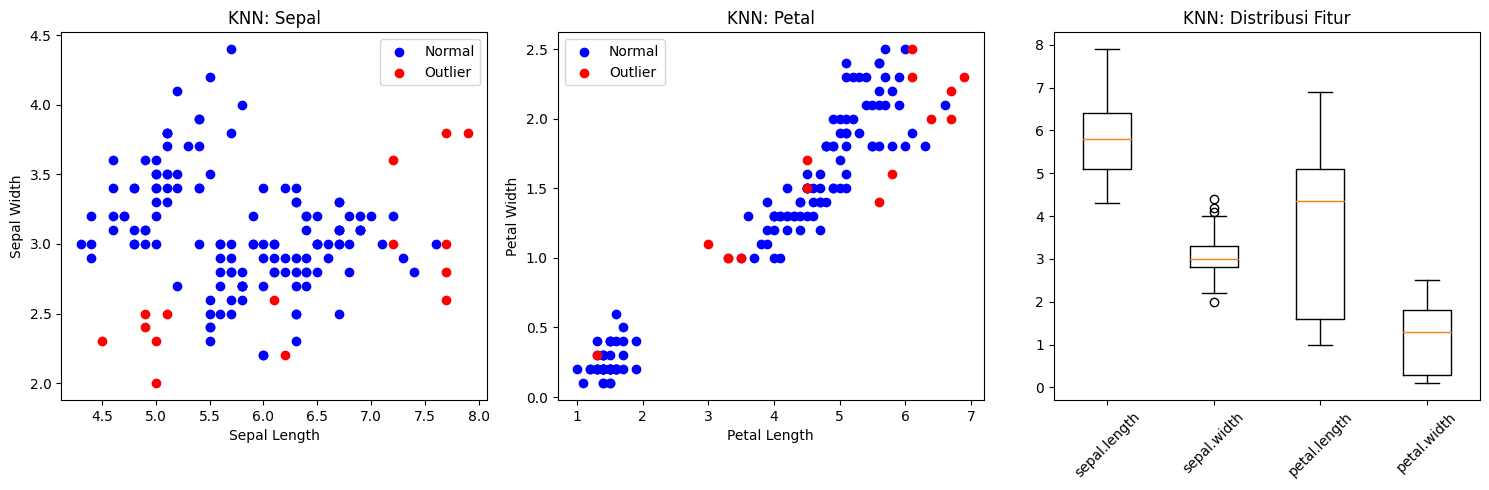


--- ABOD ---
Jumlah outlier: 15 sampel


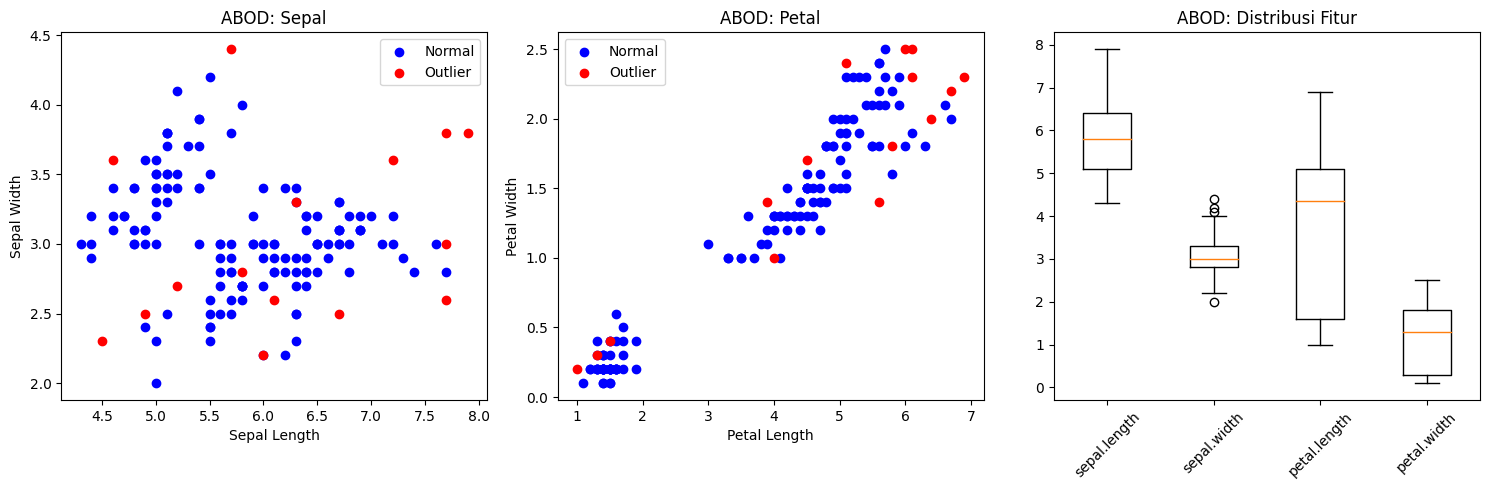


--- LOF ---
Jumlah outlier: 15 sampel


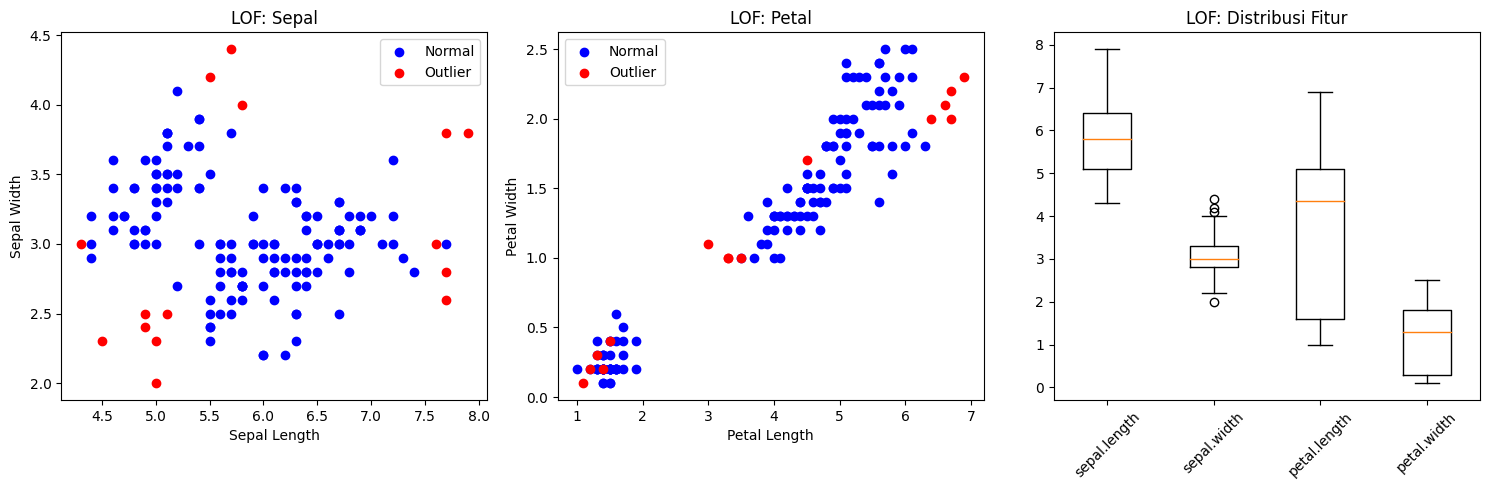


--- Ringkasan Ukuran Data ---
Ukuran data asli: (150, 6)
Setelah hapus outlier (KNN): (135, 6)
Setelah hapus outlier (ABOD): (135, 6)
Setelah hapus outlier (LOF): (135, 6)


In [9]:
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.abod import ABOD
import pandas as pd
import matplotlib.pyplot as plt

# Ambil hanya fitur numerik
features = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
cols_asli = df.columns.tolist()   # semua kolom asli biar jumlah kolom sama
X = df[features].values

# --- Metode 1: KNN ---
knn = KNN(contamination=0.1)
knn.fit(X)
df['KNN_outlier'] = knn.labels_

mask_knn = df['KNN_outlier'] == 0
df_knn_clean = df.loc[mask_knn, cols_asli].reset_index(drop=True)
df_knn_outliers = df.loc[~mask_knn, cols_asli].reset_index(drop=True)

print("\n--- KNN ---")
print(f"Jumlah outlier: {df_knn_outliers.shape[0]} sampel")

# Plot hasil KNN
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(df_knn_clean['sepal.length'], df_knn_clean['sepal.width'], c='blue', label='Normal')
plt.scatter(df_knn_outliers['sepal.length'], df_knn_outliers['sepal.width'], c='red', label='Outlier')
plt.xlabel('Sepal Length'); plt.ylabel('Sepal Width'); plt.title('KNN: Sepal'); plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(df_knn_clean['petal.length'], df_knn_clean['petal.width'], c='blue', label='Normal')
plt.scatter(df_knn_outliers['petal.length'], df_knn_outliers['petal.width'], c='red', label='Outlier')
plt.xlabel('Petal Length'); plt.ylabel('Petal Width'); plt.title('KNN: Petal'); plt.legend()

plt.subplot(1, 3, 3)
plt.boxplot([df[f] for f in features], labels=features)
plt.title('KNN: Distribusi Fitur'); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()


# --- Metode 2: ABOD ---
try:
    abod = ABOD(contamination=0.1, method='fast')
    abod.fit(X)
    df['ABOD_outlier'] = abod.labels_

    mask_abod = df['ABOD_outlier'] == 0
    df_abod_clean = df.loc[mask_abod, cols_asli].reset_index(drop=True)
    df_abod_outliers = df.loc[~mask_abod, cols_asli].reset_index(drop=True)

    print("\n--- ABOD ---")
    print(f"Jumlah outlier: {df_abod_outliers.shape[0]} sampel")

    # Plot hasil ABOD
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.scatter(df_abod_clean['sepal.length'], df_abod_clean['sepal.width'], c='blue', label='Normal')
    plt.scatter(df_abod_outliers['sepal.length'], df_abod_outliers['sepal.width'], c='red', label='Outlier')
    plt.xlabel('Sepal Length'); plt.ylabel('Sepal Width'); plt.title('ABOD: Sepal'); plt.legend()

    plt.subplot(1, 3, 2)
    plt.scatter(df_abod_clean['petal.length'], df_abod_clean['petal.width'], c='blue', label='Normal')
    plt.scatter(df_abod_outliers['petal.length'], df_abod_outliers['petal.width'], c='red', label='Outlier')
    plt.xlabel('Petal Length'); plt.ylabel('Petal Width'); plt.title('ABOD: Petal'); plt.legend()

    plt.subplot(1, 3, 3)
    plt.boxplot([df[f] for f in features], labels=features)
    plt.title('ABOD: Distribusi Fitur'); plt.xticks(rotation=45)
    plt.tight_layout(); plt.show()

except Exception as e:
    print("ABOD error di Python 3.12:", e)
    df_abod_clean = df[cols_asli].copy()
    df_abod_outliers = pd.DataFrame(columns=cols_asli)


# --- Metode 3: LOF ---
lof = LOF(contamination=0.1)
lof.fit(X)
df['LOF_outlier'] = lof.labels_

mask_lof = df['LOF_outlier'] == 0
df_lof_clean = df.loc[mask_lof, cols_asli].reset_index(drop=True)
df_lof_outliers = df.loc[~mask_lof, cols_asli].reset_index(drop=True)

print("\n--- LOF ---")
print(f"Jumlah outlier: {df_lof_outliers.shape[0]} sampel")

# Plot hasil LOF
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(df_lof_clean['sepal.length'], df_lof_clean['sepal.width'], c='blue', label='Normal')
plt.scatter(df_lof_outliers['sepal.length'], df_lof_outliers['sepal.width'], c='red', label='Outlier')
plt.xlabel('Sepal Length'); plt.ylabel('Sepal Width'); plt.title('LOF: Sepal'); plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(df_lof_clean['petal.length'], df_lof_clean['petal.width'], c='blue', label='Normal')
plt.scatter(df_lof_outliers['petal.length'], df_lof_outliers['petal.width'], c='red', label='Outlier')
plt.xlabel('Petal Length'); plt.ylabel('Petal Width'); plt.title('LOF: Petal'); plt.legend()

plt.subplot(1, 3, 3)
plt.boxplot([df[f] for f in features], labels=features)
plt.title('LOF: Distribusi Fitur'); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()


# --- Ringkasan Ukuran Data ---
print("\n--- Ringkasan Ukuran Data ---")
print("Ukuran data asli:", df[cols_asli].shape)
print("Setelah hapus outlier (KNN):", df_knn_clean.shape)
print("Setelah hapus outlier (ABOD):", df_abod_clean.shape)
print("Setelah hapus outlier (LOF):", df_lof_clean.shape)


### KNN

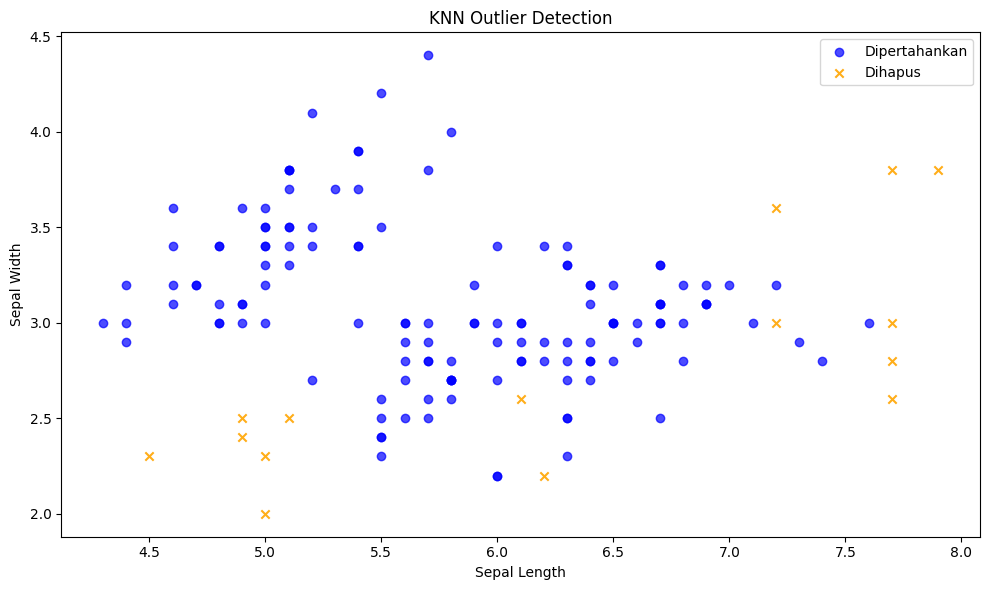

Jumlah outlier KNN: 15


In [10]:
# --- Implementasi KNN Outlier Detection ---
from pyod.models.knn import KNN
import matplotlib.pyplot as plt

# Inisialisasi model KNN
knn = KNN(contamination=0.1, n_neighbors=5)

# Fit dan prediksi (0 = normal, 1 = outlier)
knn.fit(X)
labels_knn = knn.labels_

# Tambahkan hasil ke dataframe
df['KNN_outlier'] = labels_knn

# Pisahkan data normal dan outlier
normal_knn = df[df['KNN_outlier'] == 0]
outlier_knn = df[df['KNN_outlier'] == 1]

# --- Plot sesuai gaya baru ---
plt.figure(figsize=(10, 6))
plt.scatter(normal_knn['sepal.length'], normal_knn['sepal.width'], 
            c='blue', marker='o', label='Dipertahankan', alpha=0.7)
plt.scatter(outlier_knn['sepal.length'], outlier_knn['sepal.width'], 
            c='orange', marker='x', label='Dihapus', alpha=0.9)

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('KNN Outlier Detection')
plt.legend()
plt.tight_layout()
plt.show()

# Tampilkan jumlah outlier
print(f"Jumlah outlier KNN: {outlier_knn.shape[0]}")


### ABOD

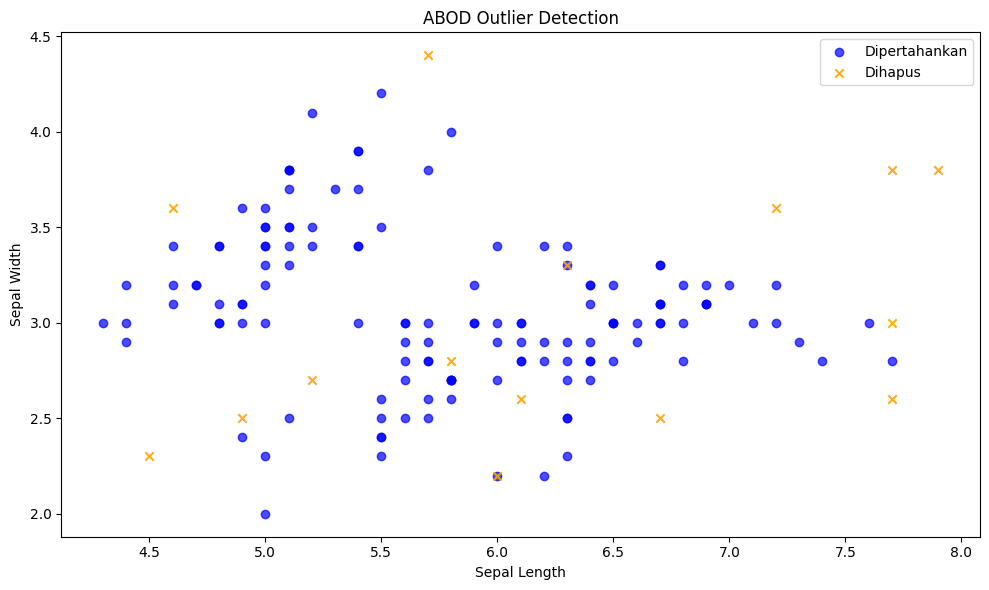

Jumlah outlier ABOD: 15


In [11]:
# --- Implementasi ABOD Outlier Detection ---
from pyod.models.abod import ABOD

abod = ABOD(contamination=0.1, method='fast')
abod.fit(X)
labels_abod = abod.labels_

df['ABOD_outlier'] = labels_abod

# Pisahkan data normal dan outlier
normal_abod = df[df['ABOD_outlier'] == 0]
outlier_abod = df[df['ABOD_outlier'] == 1]

# --- Plot sesuai gaya baru ---
plt.figure(figsize=(10, 6))
plt.scatter(normal_abod['sepal.length'], normal_abod['sepal.width'], 
            c='blue', marker='o', label='Dipertahankan', alpha=0.7)
plt.scatter(outlier_abod['sepal.length'], outlier_abod['sepal.width'], 
            c='orange', marker='x', label='Dihapus', alpha=0.9)

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('ABOD Outlier Detection')
plt.legend()
plt.tight_layout()
plt.show()

# Info jumlah outlier
print(f"Jumlah outlier ABOD: {outlier_abod.shape[0]}")


### LOF

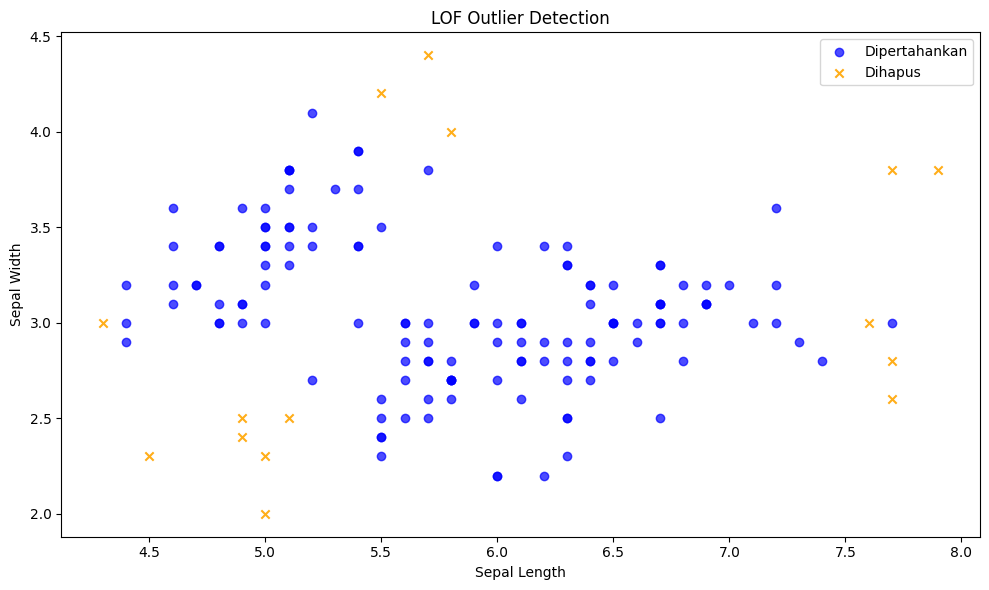

Jumlah outlier LOF: 15


In [12]:
# --- Implementasi LOF Outlier Detection ---
from pyod.models.lof import LOF

lof = LOF(contamination=0.1)
lof.fit(X)
labels_lof = lof.labels_

df['LOF_outlier'] = labels_lof

# Pisahkan data normal dan outlier
normal_lof = df[df['LOF_outlier'] == 0]
outlier_lof = df[df['LOF_outlier'] == 1]

# --- Plot sesuai gaya baru ---
plt.figure(figsize=(10, 6))
plt.scatter(normal_lof['sepal.length'], normal_lof['sepal.width'], 
            c='blue', marker='o', label='Dipertahankan', alpha=0.7)
plt.scatter(outlier_lof['sepal.length'], outlier_lof['sepal.width'], 
            c='orange', marker='x', label='Dihapus', alpha=0.9)

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('LOF Outlier Detection')
plt.legend()
plt.tight_layout()
plt.show()

# Info jumlah outlier
print(f"Jumlah outlier LOF: {outlier_lof.shape[0]}")


### Deteksi Outlier dengan Pendekatan Voting Menggunakan KNN, LOF, dan ABOD

Pada pendeteksiab outlier pada dataset ini saya memanfaatkan tiga metode berbeda, yaitu KNN (K-Nearest Neighbors), LOF (Local Outlier Factor), dan ABOD (Angle-Based Outlier Detection). Dimana pada setiap metode memberikan label pada data apakah termasuk normal (0) atau outlier (1). Dan hasil dari ketiga metode tersebut kemudian digabungkan dalam bentuk voting, yaitu menjumlahkan jumlah metode yang menandai suatu data sebagai outlier. Dengan cara ini, data yang mendapatkan lebih banyak “suara outlier” dianggap memiliki kemungkinan lebih besar sebagai data pencilan sehingga proses identifikasi menjadi lebih kuat dan tidak hanya bergantung pada satu metode saja.

In [13]:
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.abod import ABOD

# --- Ambil hanya fitur numerik ---
X = df.select_dtypes("number")
features = X.columns.tolist()

# --- Metode 1: KNN ---
knn = KNN()
knn.fit(X)
df['outlier_knn'] = knn.labels_

# --- Metode 2: LOF ---
lof = LOF()
lof.fit(X)
df['outlier_lof'] = lof.labels_

# --- Metode 3: ABOD ---
abod = ABOD()
abod.fit(X)
df['outlier_abod'] = abod.labels_

# --- Voting outlier ---
df['total_outlier_votes'] = (
    df['outlier_knn'] + df['outlier_lof'] + df['outlier_abod']
)

# Cek dulu hasil voting
print(df[['outlier_knn','outlier_lof','outlier_abod','total_outlier_votes']].head())


   outlier_knn  outlier_lof  outlier_abod  total_outlier_votes
0            0            0             0                    0
1            0            0             0                    0
2            0            0             0                    0
3            0            0             0                    0
4            0            0             0                    0


### Pembersihan Data Outlier dengan Sistem Voting (KNN, ABOD, LOF)

Pada pembersihan data dari outlier dengan cara menggabungkan hasil deteksi dari tiga metode (KNN, ABOD, LOF). Dimana untuk setiap metode dikasi label apakah sebuah data termasuk outlier atau tidak. dan Label tersebut dijumlahkan dalam kolom total_outlier_votes, sehingga semakin tinggi nilainya, semakin besar kemungkinan data itu adalah outlier. Kemudian, data yang memiliki jumlah voting ≥ 2 dianggap outlier dan dihapus, sedangkan sisanya dipertahankan dalam dataset baru df_clean. Hasilnya divisualisasikan dengan: 
- Pie chart untuk menunjukkan distribusi jumlah voting outlier, 
- Violin plot untuk membandingkan distribusi fitur sebelum dan sesudah pembersihan, 
- Scatter plot untuk memperlihatkan data yang dipertahankan dan data yang dihapus. 

Selain itu, juga menampilkan statistik deskriptif sebelum dan sesudah pembersihan serta menyimpan dataset bersih ke file iris_preprocessed.csv.

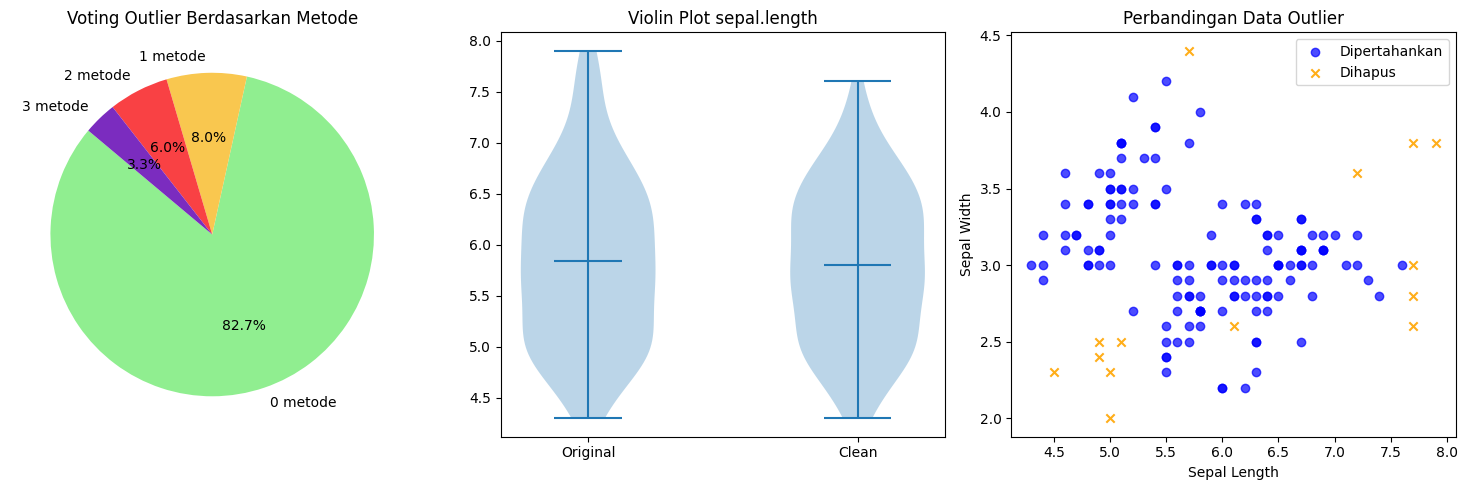

-- Hasil Preprocessing Data --
- Total data awal             : 150
- Data yang dihapus           : 14 (9.33%)
- Total data setelah bersih   : 136

-- Statistik Deskriptif Sebelum & Sesudah --

>> Sebelum penghapusan outlier:
       sepal.length  sepal.width  petal.length  petal.width        vnum  \
count    150.000000   150.000000    150.000000   150.000000  150.000000   
mean       5.843333     3.057333      3.758000     1.199333    1.000000   
std        0.828066     0.435866      1.765298     0.762238    0.819232   
min        4.300000     2.000000      1.000000     0.100000    0.000000   
25%        5.100000     2.800000      1.600000     0.300000    0.000000   
50%        5.800000     3.000000      4.350000     1.300000    1.000000   
75%        6.400000     3.300000      5.100000     1.800000    2.000000   
max        7.900000     4.400000      6.900000     2.500000    2.000000   

       KNN_outlier  ABOD_outlier  LOF_outlier  
count   150.000000    150.000000   150.000000  
mea

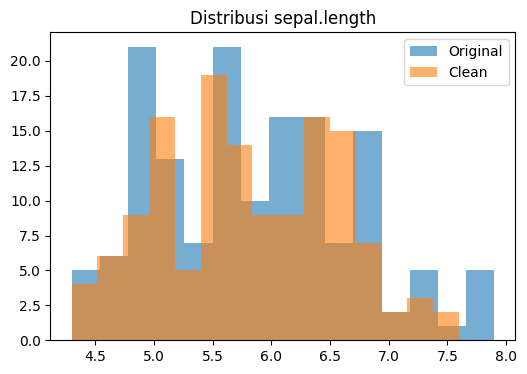

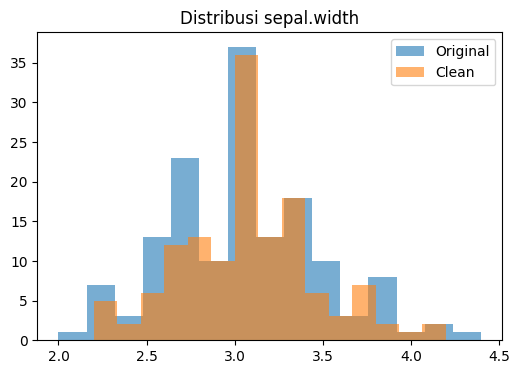

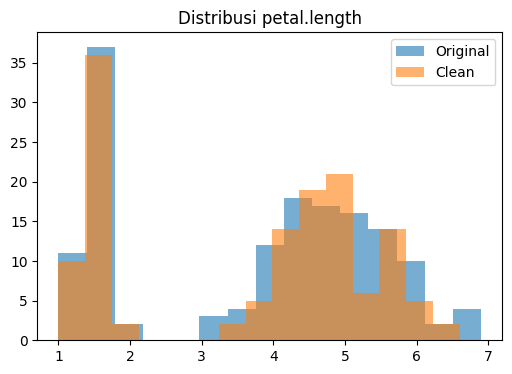

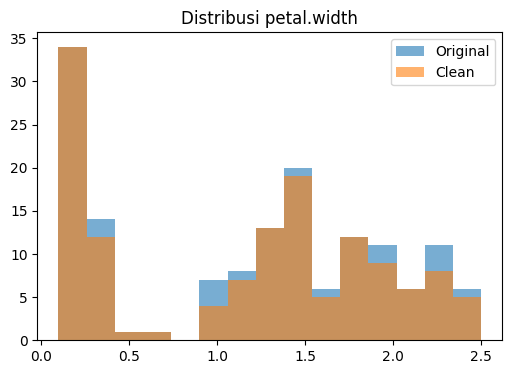

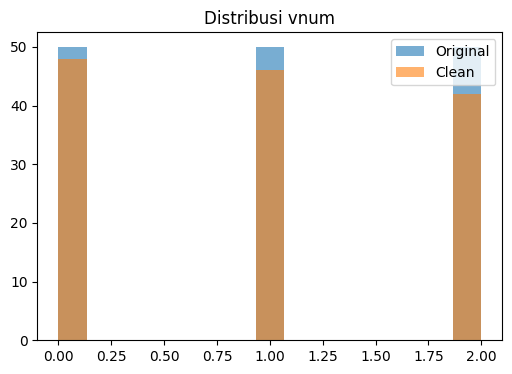

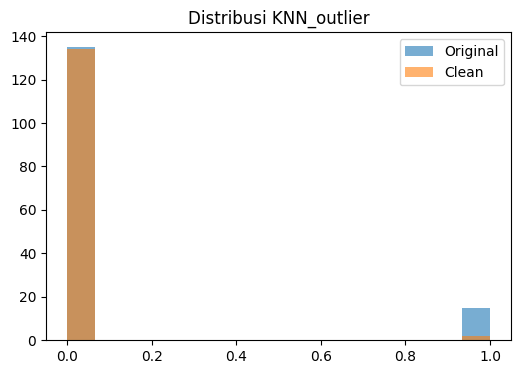

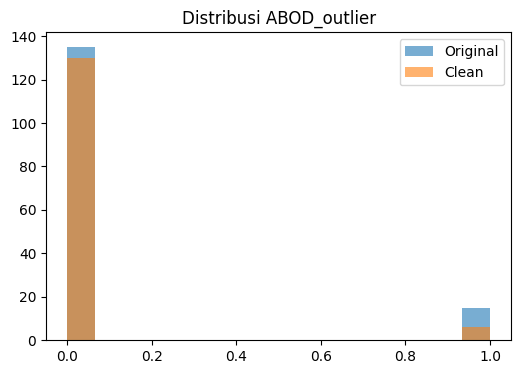

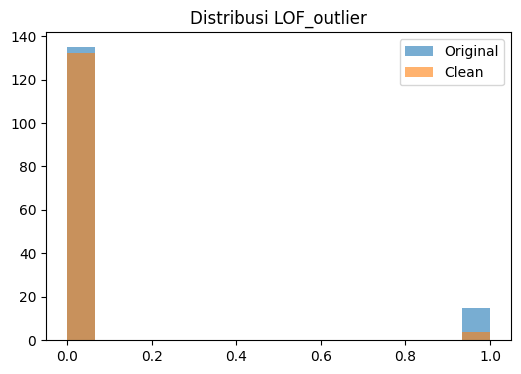


Dataset hasil preprocessing telah disimpan sebagai 'iris_preprocessed.csv'


In [14]:
# --- Hitung total outlier dari semua metode (KNN, ABOD, LOF) ---
df['total_outlier_votes'] = df[['KNN_outlier', 'ABOD_outlier', 'LOF_outlier']].sum(axis=1)

# --- Menghapus outlier berdasarkan sistem voting ---
df_clean = df[df['total_outlier_votes'] < 2].copy()

# Visualisasi hasil voting
plt.figure(figsize=(15, 5))

# Plot 1: Pie chart hasil voting
plt.subplot(1, 3, 1)
votes_count = df['total_outlier_votes'].value_counts().sort_index()
plt.pie(votes_count, 
        labels=[f'{i} metode' for i in votes_count.index], 
        autopct='%1.1f%%', 
        colors=['#90ee90', '#f9c74f', '#f94144', '#7b2cbf'], 
        startangle=140)
plt.title('Voting Outlier Berdasarkan Metode')

# Plot 2: Violin plot perbandingan sebelum & sesudah
plt.subplot(1, 3, 2)
plt.violinplot([df[features[0]], df_clean[features[0]]], showmeans=True)
plt.xticks([1, 2], ['Original', 'Clean'])
plt.title(f'Violin Plot {features[0]}')

# Plot 3: Scatter plot data dipertahankan vs dihapus
plt.subplot(1, 3, 3)
plt.scatter(df_clean['sepal.length'], df_clean['sepal.width'], 
            c='blue', marker='o', label='Dipertahankan', alpha=0.7)
plt.scatter(df[df['total_outlier_votes'] >= 2]['sepal.length'], 
            df[df['total_outlier_votes'] >= 2]['sepal.width'], 
            c='orange', marker='x', label='Dihapus', alpha=0.9)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Perbandingan Data Outlier')
plt.legend()
plt.tight_layout()
plt.show()

# Statistik hasil preprocessing
print("-- Hasil Preprocessing Data --")
print("="*50)
print(f"- Total data awal             : {len(df)}")
print(f"- Data yang dihapus           : {len(df) - len(df_clean)} "
      f"({(len(df) - len(df_clean)) / len(df) * 100:.2f}%)")
print(f"- Total data setelah bersih   : {len(df_clean)}")

print("\n-- Statistik Deskriptif Sebelum & Sesudah --")
print("="*50)
print("\n>> Sebelum penghapusan outlier:")
print(df[features].describe())
print("\n>> Setelah penghapusan outlier:")
print(df_clean[features].describe())

# Visualisasi distribusi tiap fitur sebelum & sesudah
for feature in features:
    plt.figure(figsize=(6, 4))
    plt.hist(df[feature], bins=15, alpha=0.6, label='Original')
    plt.hist(df_clean[feature], bins=15, alpha=0.6, label='Clean')
    plt.title(f'Distribusi {feature}')
    plt.legend()
    plt.show()


# Menyimpan dataset hasil preprocessing
df_clean[features + ['variety']].to_csv('iris_preprocessed.csv', index=False)
print("\nDataset hasil preprocessing telah disimpan sebagai 'iris_preprocessed.csv'")
